# Schema and BG/NBD

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import pymc as pm
import arviz as az
import pymc_marketing
from pymc_marketing.clv import ParetoNBDModel, BetaGeoModel

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

from lifetimes.utils import summary_data_from_transaction_data
from lifetimes import BetaGeoFitter, GammaGammaFitter, ParetoNBDFitter


from pymc_marketing.clv import ParetoNBDModel, rfm_summary
import inspect

from scipy.stats import pearsonr, spearmanr


In [2]:
df = pd.read_csv('clean_purchase.csv')

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 799406 entries, 0 to 799405
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   line_id      799406 non-null  int64         
 1   Invoice      799406 non-null  int64         
 2   StockCode    799406 non-null  str           
 3   Description  799406 non-null  str           
 4   Quantity     799406 non-null  int64         
 5   InvoiceDate  799406 non-null  datetime64[us]
 6   Price        799406 non-null  float64       
 7   Customer ID  799406 non-null  int64         
 8   Country      799406 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(4), str(3)
memory usage: 54.9 MB


In [4]:
df['line_amount'] = df['Price']*df['Quantity']

# Customer-level totals
customer_price_stats = (
    df.groupby('Customer ID', as_index=False)
      .agg(
          total_quantity=('Quantity', 'sum'),
          total_line_amount=('line_amount', 'sum')
      )
)

# Average item price per customer
customer_price_stats['avg_item_price'] = (
    customer_price_stats['total_line_amount']
    / customer_price_stats['total_quantity']
)

# Customers to keep:
# avg_item_price > 0 and <= 1000
valid_customers = customer_price_stats.loc[
    (customer_price_stats['avg_item_price'] > 0) &
    (customer_price_stats['avg_item_price'] <= 100),
    'Customer ID'
]

# Filter the original dataframe
df = df[df['Customer ID'].isin(valid_customers)].copy()

print("Remaining rows:", len(df))
print("Remaining customers:", df['Customer ID'].nunique())

removed_customers = customer_price_stats.loc[
    (customer_price_stats['avg_item_price'] <= 0) |
    (customer_price_stats['avg_item_price'] > 100)
]

print("Customers removed:", len(removed_customers))

Remaining rows: 799381
Remaining customers: 5842
Customers removed: 20


In [5]:
## creating invoice table: Group by customer and invoice, then sum the costs and quantities
df_invoice = df.groupby(['Invoice', 'Customer ID','InvoiceDate', 'Country']).agg(
    total_amount=('line_amount', 'sum'),
    number_of_items=('Quantity', 'sum')
).reset_index()

In [6]:
### Creating product table
df_product = (
    df.groupby('StockCode', as_index=False)['Description']
      .first()
)

In [7]:
df.drop(columns=['Customer ID','InvoiceDate', 'Country', 'Description'], inplace=True)

df.to_csv('line.csv', index=False)
df_invoice.to_csv("invoice.csv", index=False)
df_product.to_csv('product.csv', index=False)

In [8]:
# make a copy
df_modified = df_invoice.copy()

# extract date only from date-time
df_modified["order_date"] = df_modified["InvoiceDate"].dt.date

# group same customer + same day into one order
df_modified = (
    df_modified
    .groupby(["Customer ID", "order_date"], as_index=False)
    .agg(
        total_amount=("total_amount", "sum"),
        number_of_items=("number_of_items", "sum"),
        Country=("Country", "first"),
        InvoiceDate=('InvoiceDate', 'first')
    )
)


# create order_id as string: customer id + date
df_modified["order_id"] = (
    df_modified["Customer ID"].astype(str) + "_" +
    pd.to_datetime(df_modified["order_date"]).dt.strftime("%Y-%m-%d")
)

df_modified.info()

<class 'pandas.DataFrame'>
RangeIndex: 32909 entries, 0 to 32908
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Customer ID      32909 non-null  int64         
 1   order_date       32909 non-null  object        
 2   total_amount     32909 non-null  float64       
 3   number_of_items  32909 non-null  int64         
 4   Country          32909 non-null  str           
 5   InvoiceDate      32909 non-null  datetime64[us]
 6   order_id         32909 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), object(1), str(2)
memory usage: 1.8+ MB


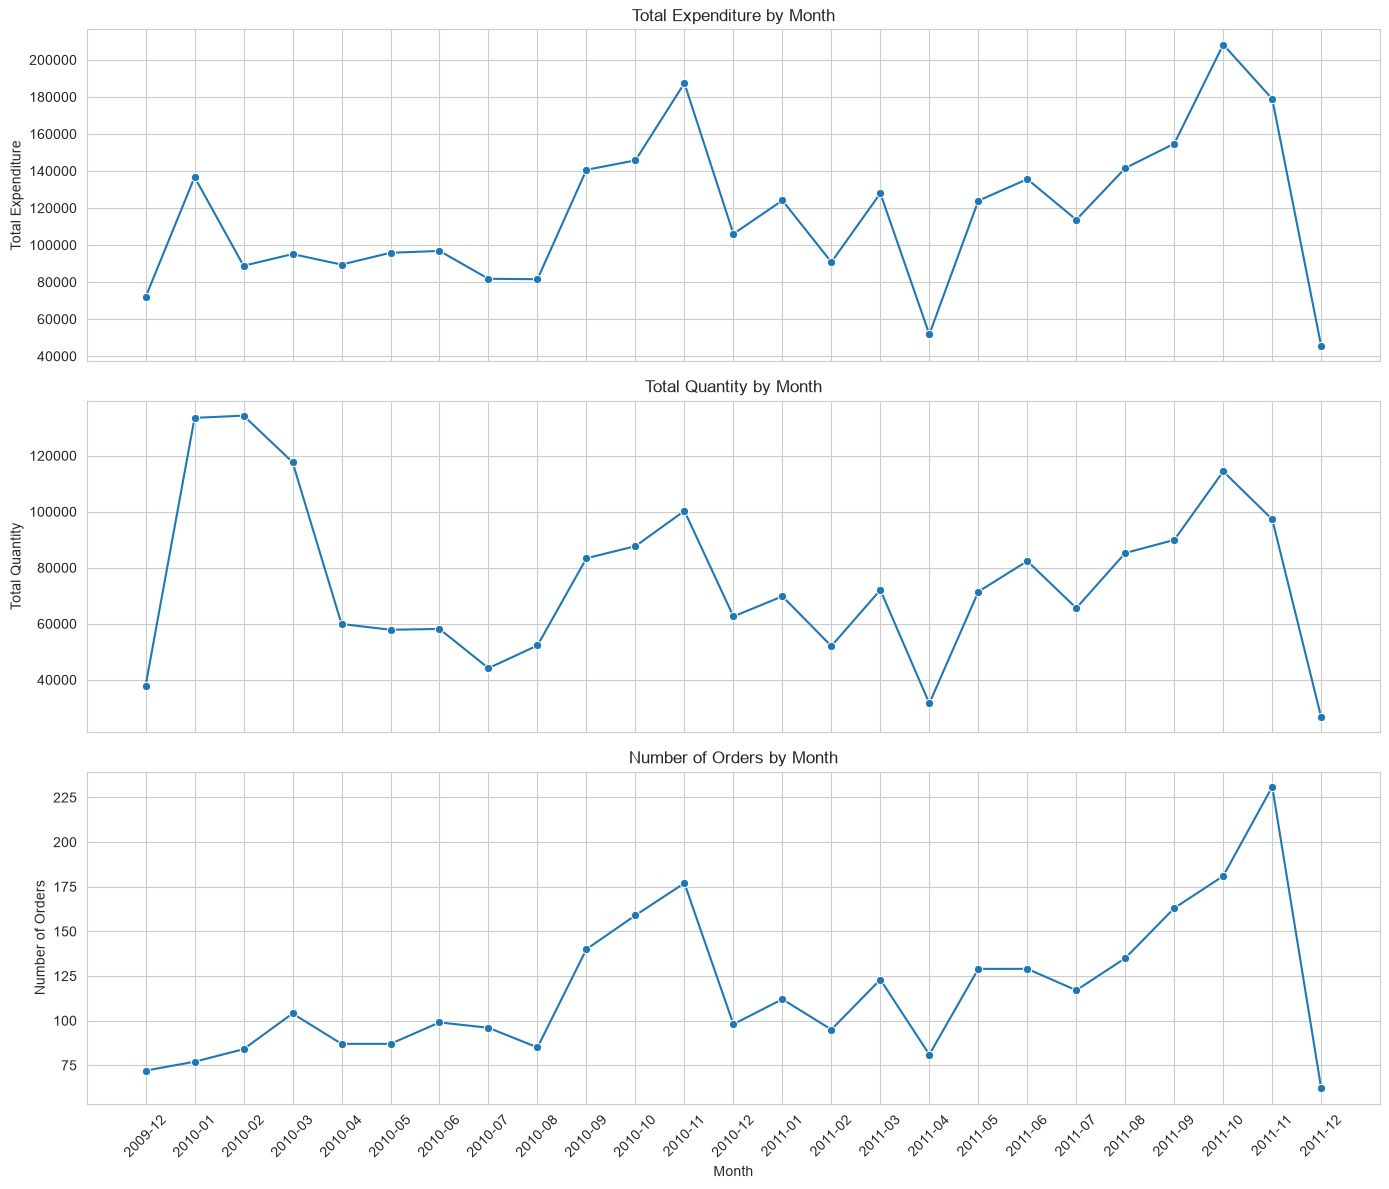

In [9]:
# make sure order_date is datetime
df_modified["order_date"] = pd.to_datetime(df_modified["order_date"])

df_modified_temp = df_modified[df_modified['Country']!='UNITED KINGDOM']

# monthly aggregation
monthly = (
    df_modified_temp
    .assign(month=df_modified_temp["order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(
        total_expenditure=("total_amount", "sum"),
        total_quantity=("number_of_items", "sum"),
        number_of_orders=("order_id", "nunique")
    )
    .sort_values("month")
)

monthly["month_label"] = monthly["month"].dt.strftime("%Y-%m")

sns.set_style("whitegrid")

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

sns.lineplot(data=monthly, x="month_label", y="total_expenditure", marker="o", ax=axes[0])
axes[0].set_title("Total Expenditure by Month")
axes[0].set_xlabel("")
axes[0].set_ylabel("Total Expenditure")

sns.lineplot(data=monthly, x="month_label", y="total_quantity", marker="o", ax=axes[1])
axes[1].set_title("Total Quantity by Month")
axes[1].set_xlabel("")
axes[1].set_ylabel("Total Quantity")

sns.lineplot(data=monthly, x="month_label", y="number_of_orders", marker="o", ax=axes[2])
axes[2].set_title("Number of Orders by Month")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Number of Orders")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Spliting 

In [10]:
# Determine split date ( of the time span)
min_date = df_modified['InvoiceDate'].min()
max_date = df_modified['InvoiceDate'].max()

split_date = min_date + (max_date - min_date)* 0.5

print(f"min_date: {min_date}, Split date: {split_date}, max_date: {max_date}")

# Split into calibration and holdout
df_calibration = df_modified[df_modified['InvoiceDate'] < split_date].copy()
df_holdout = df_modified[df_modified['InvoiceDate'] >= split_date].copy()

print("Calibration:", df_calibration.shape)
print("Holdout:", df_holdout.shape)

print("Calibration period:")
print(df_calibration['InvoiceDate'].min(), "to", df_calibration['InvoiceDate'].max())

print("Holdout period:")
print(df_holdout['InvoiceDate'].min(), "to", df_holdout['InvoiceDate'].max())

min_date: 2009-12-01 07:45:00, Split date: 2010-12-05 10:17:30, max_date: 2011-12-09 12:50:00
Calibration: (16478, 7)
Holdout: (16431, 7)
Calibration period:
2009-12-01 07:45:00 to 2010-12-05 10:12:00
Holdout period:
2010-12-05 10:27:00 to 2011-12-09 12:50:00


In [11]:
df_calibration.info()

<class 'pandas.DataFrame'>
Index: 16478 entries, 0 to 32905
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Customer ID      16478 non-null  int64         
 1   order_date       16478 non-null  datetime64[s] 
 2   total_amount     16478 non-null  float64       
 3   number_of_items  16478 non-null  int64         
 4   Country          16478 non-null  str           
 5   InvoiceDate      16478 non-null  datetime64[us]
 6   order_id         16478 non-null  str           
dtypes: datetime64[s](1), datetime64[us](1), float64(1), int64(2), str(2)
memory usage: 1.0 MB


In [12]:
df_holdout.info()

<class 'pandas.DataFrame'>
Index: 16431 entries, 8 to 32908
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Customer ID      16431 non-null  int64         
 1   order_date       16431 non-null  datetime64[s] 
 2   total_amount     16431 non-null  float64       
 3   number_of_items  16431 non-null  int64         
 4   Country          16431 non-null  str           
 5   InvoiceDate      16431 non-null  datetime64[us]
 6   order_id         16431 non-null  str           
dtypes: datetime64[s](1), datetime64[us](1), float64(1), int64(2), str(2)
memory usage: 1.0 MB


In [13]:
# sort chronologically
df_sorted = df_calibration.sort_values(
    ["InvoiceDate", "Customer ID", "order_id"]
).reset_index(drop=True)

n = len(df_sorted)

start_time = df_sorted["InvoiceDate"].min()
end_time = df_sorted["InvoiceDate"].max()

## time-warping / de-seasonalization step.
span_seconds = (end_time - start_time).total_seconds()

# rank-based effective time in [0, 1]
if n == 1:
    df_sorted["effective_u"] = 0.0
else:
    df_sorted["effective_u"] = np.arange(n) / (n - 1)

# map to actual calendar span
df_sorted["effective_time"] = start_time + pd.to_timedelta(
    df_sorted["effective_u"] * span_seconds,
    unit="s"
)

df_sorted["effective_time2"] = (
    df_sorted["InvoiceDate"]
    + (df_sorted["effective_time"] - df_sorted["InvoiceDate"]) / 2
)

df_sorted.drop(columns=['effective_u', 'InvoiceDate'], inplace=True)
df_sorted.info()
df_sorted.to_csv('with_scaled_time.csv')



<class 'pandas.DataFrame'>
RangeIndex: 16478 entries, 0 to 16477
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Customer ID      16478 non-null  int64         
 1   order_date       16478 non-null  datetime64[s] 
 2   total_amount     16478 non-null  float64       
 3   number_of_items  16478 non-null  int64         
 4   Country          16478 non-null  str           
 5   order_id         16478 non-null  str           
 6   effective_time   16478 non-null  datetime64[ns]
 7   effective_time2  16478 non-null  datetime64[ns]
dtypes: datetime64[ns](2), datetime64[s](1), float64(1), int64(2), str(2)
memory usage: 1.0 MB


In [14]:
summary_cal = summary_data_from_transaction_data(
    transactions=df_sorted,
    customer_id_col='Customer ID',
    datetime_col='effective_time',
    monetary_value_col='total_amount',
    observation_period_end=split_date
)

summary_cal.info()

<class 'pandas.DataFrame'>
Index: 4261 entries, 12346 to 18287
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   frequency       4261 non-null   float64
 1   recency         4261 non-null   float64
 2   T               4261 non-null   float64
 3   monetary_value  4261 non-null   float64
dtypes: float64(4)
memory usage: 166.4 KB


## Fitting Pareto/NBD Using pymc marketing

In [15]:
summary_cal = rfm_summary(
    transactions=df_sorted,
    customer_id_col="Customer ID",
    datetime_col="effective_time",
    monetary_value_col="total_amount",
    observation_period_end=df_sorted["effective_time"].max(),
    time_unit="D",
)

In [16]:
# Fit Pareto/NBD
model = ParetoNBDModel(data=summary_cal)
model.fit(fit_method="map")

/var/folders/4r/vm13n_b12fs76dfl4t5yvkw40000gn/T/ipykernel_63760/2736262712.py:3: DeprecationWarning: 'fit_method' is deprecated and will be removed in version 1.0. Use 'method' instead.
  model.fit(fit_method="map")


Output()

Inference data with groups:
	> posterior
	> observed_data
	> fit_data

## Churn and zero purchase in the holdout period

In [17]:
holdout_period = (
    df_holdout["InvoiceDate"].max() -
    df_holdout["InvoiceDate"].min()
).days

In [18]:
# probability customer is alive after calibration
p_alive = model.expected_probability_alive(data=summary_cal)

evaluation = summary_cal.copy()
evaluation["p_alive"] = np.asarray(p_alive).ravel()

# actual churn = no purchase in holdout
holdout_customers = set(df_holdout["Customer ID"].unique())
evaluation["actual_churned"] = (~evaluation["customer_id"].isin(holdout_customers)).astype(int)

# predicted churn = 1 - p_alive
evaluation["pred_churn_prob"] = 1 - evaluation["p_alive"]
evaluation["pred_churned"] = (evaluation["pred_churn_prob"] >= 0.5).astype(int)

y_true = evaluation["actual_churned"]
y_pred = evaluation["pred_churned"]
y_score = evaluation["pred_churn_prob"]

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

print("ROC AUC:")
print(roc_auc_score(y_true, y_score))

Confusion Matrix:
[[2697    3]
 [1553    8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      1.00      0.78      2700
           1       0.73      0.01      0.01      1561

    accuracy                           0.63      4261
   macro avg       0.68      0.50      0.39      4261
weighted avg       0.67      0.63      0.50      4261

ROC AUC:
0.7472701497140959


In [19]:
evaluation["p0"] = np.asarray(
    model.expected_purchase_probability(
        data=summary_cal,
        n_purchases=0,
        future_t=holdout_period
    )
).ravel()

actual = df_holdout.groupby("Customer ID")["order_id"].nunique()
evaluation["actual_purchases"] = evaluation["customer_id"].map(actual).fillna(0)

expected_no_purchase = evaluation["p0"].sum()



# Probability alive for each customer
p_alive = model.expected_probability_alive(data=summary_cal)

evaluation["p_alive"] = np.asarray(p_alive).ravel()

# Expected numbers
expected_alive = evaluation["p_alive"].sum()
expected_churned = len(evaluation) - expected_alive

# Actual number of churned customers
holdout_customers = set(df_holdout["Customer ID"].unique())
actual_churned = (
    ~evaluation["customer_id"].isin(holdout_customers)
).sum()


expected_no_purchase = evaluation["p0"].sum()
actual_no_purchase = (evaluation["actual_purchases"] == 0).sum()


print(f"Number of customers        : {len(evaluation)}")
print(f"Expected alive customers   : {expected_alive:.2f}")
print(f"Expected churned customers : {expected_churned:.2f}")
print(f"Actual churned customers   : {actual_churned}")


print(f"Expected customers with no purchase : {expected_no_purchase:.2f}")
print(f"Actual customers with no purchase   : {actual_no_purchase}")

Number of customers        : 4261
Expected alive customers   : 4153.20
Expected churned customers : 107.80
Actual churned customers   : 1561
Expected customers with no purchase : 1047.59
Actual customers with no purchase   : 1561


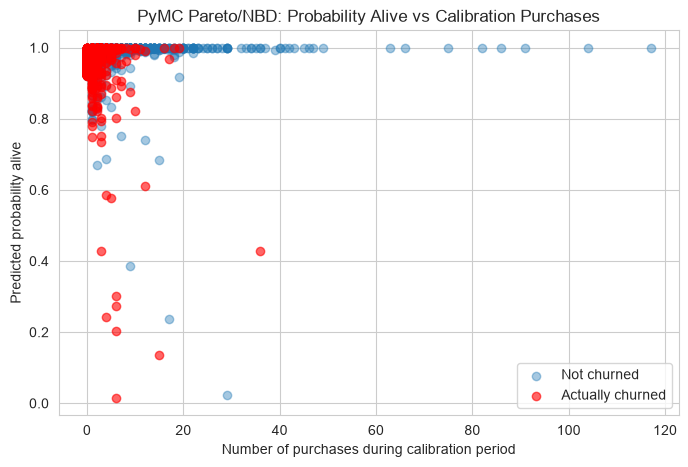

In [20]:
holdout_customers = set(df_holdout["Customer ID"].unique())

evaluation["actual_churned"] = (
    ~evaluation["customer_id"].isin(holdout_customers)
).astype(int)

plot_data = evaluation.dropna(subset=["p_alive"]).copy()

not_churned = plot_data[plot_data["actual_churned"] == 0]
churned = plot_data[plot_data["actual_churned"] == 1]

plt.figure(figsize=(8, 5))

plt.scatter(
    not_churned["frequency"],
    not_churned["p_alive"],
    alpha=0.4,
    label="Not churned"
)

plt.scatter(
    churned["frequency"],
    churned["p_alive"],
    color="red",
    alpha=0.6,
    label="Actually churned"
)

plt.xlabel("Number of purchases during calibration period")
plt.ylabel("Predicted probability alive")
plt.title("PyMC Pareto/NBD: Probability Alive vs Calibration Purchases")
plt.grid(True)
plt.legend()
plt.show()

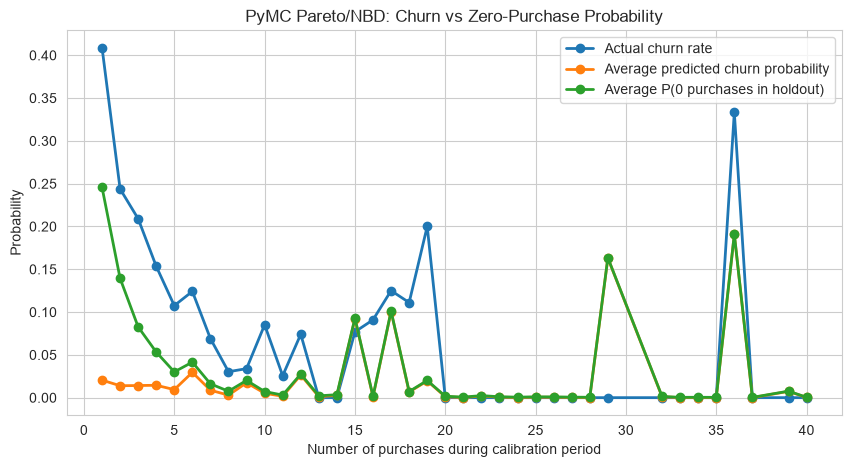

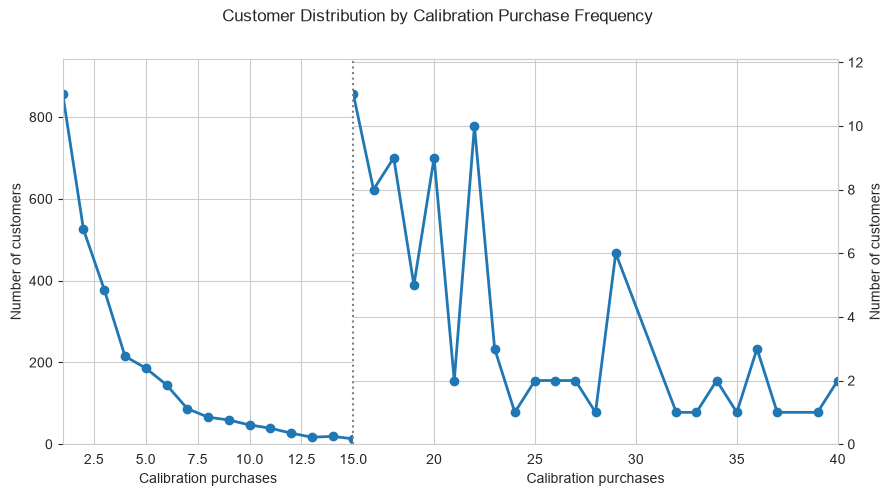

In [46]:
import numpy as np
import matplotlib.pyplot as plt

holdout_customers = set(df_holdout["Customer ID"].unique())

evaluation["actual_churned"] = (
    ~evaluation["customer_id"].isin(holdout_customers)
).astype(int)

evaluation["p_alive"] = np.asarray(
    model.expected_probability_alive(data=summary_cal)
).ravel()

evaluation["p0"] = np.asarray(
    model.expected_purchase_probability(
        data=summary_cal,
        n_purchases=0,
        future_t=holdout_period
    )
).ravel()

plot_data = evaluation.dropna(subset=["p_alive", "p0", "actual_churned"]).copy()
plot_data["pred_churn_prob"] = 1 - plot_data["p_alive"]

freq_summary = (
    plot_data[
        (plot_data["frequency"] >= 1) &
        (plot_data["frequency"] <= 40)
    ]
    .groupby("frequency")
    .agg(
        actual_churn_rate=("actual_churned", "mean"),
        avg_pred_churn_prob=("pred_churn_prob", "mean"),
        avg_p0=("p0", "mean"),
        n_customers=("actual_churned", "size")
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(freq_summary["frequency"], freq_summary["actual_churn_rate"], marker="o", linewidth=2, label="Actual churn rate")
plt.plot(freq_summary["frequency"], freq_summary["avg_pred_churn_prob"], marker="o", linewidth=2, label="Average predicted churn probability")
plt.plot(freq_summary["frequency"], freq_summary["avg_p0"], marker="o", linewidth=2, label="Average P(0 purchases in holdout)")
plt.xlabel("Number of purchases during calibration period")
plt.ylabel("Probability")
plt.title("PyMC Pareto/NBD: Churn vs Zero-Purchase Probability")
plt.grid(True)
plt.legend()
plt.show()


#===================================================================
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(10, 5),
    gridspec_kw={"width_ratios": [15, 25]},
    sharex=False,
    sharey=False
)

left = freq_summary[freq_summary["frequency"] <= 15]
right = freq_summary[freq_summary["frequency"] >= 16]

ax1.plot(left["frequency"], left["n_customers"], marker="o", linewidth=2)
ax2.plot(right["frequency"], right["n_customers"], marker="o", linewidth=2)

# x limits
ax1.set_xlim(1, 15)
ax2.set_xlim(16, 40)

# independent y limits
ax1.set_ylim(0, left["n_customers"].max() * 1.1)
ax2.set_ylim(0, right["n_customers"].max() * 1.1)

# remove touching spines
ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)

# left y-axis
ax1.yaxis.set_ticks_position("left")
ax1.yaxis.set_label_position("left")
ax1.set_ylabel("Number of customers")

# right y-axis
ax2.yaxis.set_ticks_position("right")
ax2.yaxis.set_label_position("right")
ax2.set_ylabel("Number of customers")

# x labels
ax1.set_xlabel("Calibration purchases")
ax2.set_xlabel("Calibration purchases")

# dotted separator
ax1.axvline(
    x=15,
    color="gray",
    linestyle=":",
    linewidth=1.5
)

ax2.axvline(
    x=16,
    color="gray",
    linestyle=":",
    linewidth=1.5
)

fig.suptitle("Customer Distribution by Calibration Purchase Frequency")

# panels touch each other
plt.subplots_adjust(wspace=0)

plt.show()

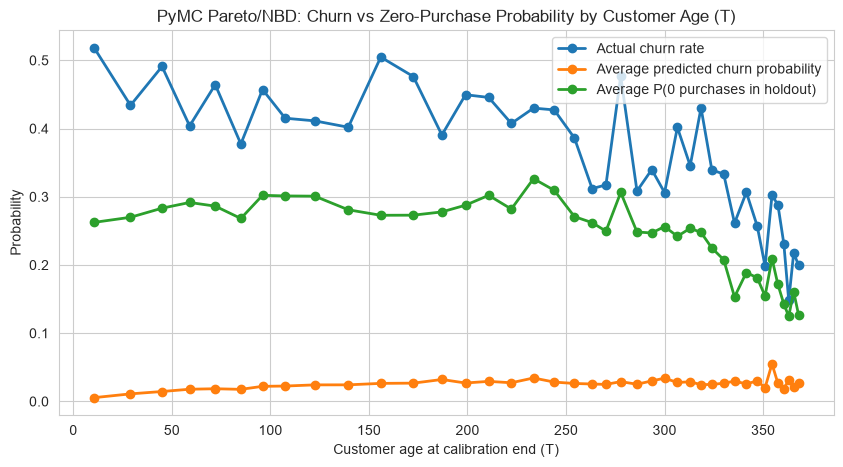

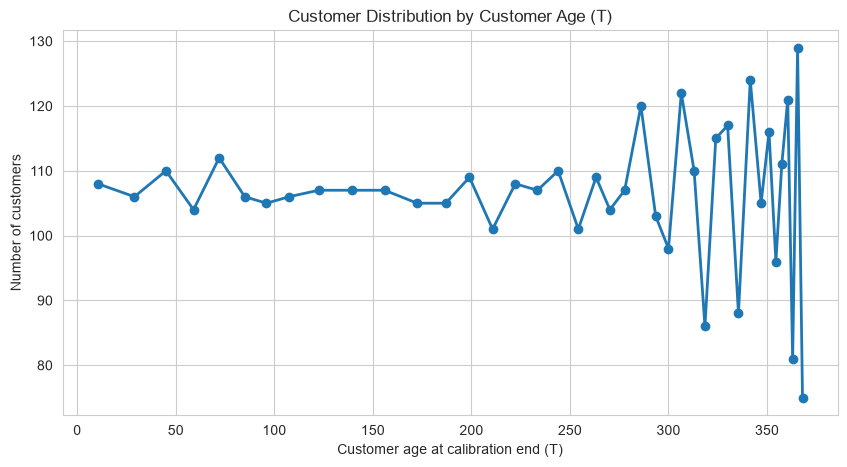

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

holdout_customers = set(df_holdout["Customer ID"].unique())

evaluation["actual_churned"] = (
    ~evaluation["customer_id"].isin(holdout_customers)
).astype(int)

evaluation["p_alive"] = np.asarray(
    model.expected_probability_alive(data=summary_cal)
).ravel()

evaluation["p0"] = np.asarray(
    model.expected_purchase_probability(
        data=summary_cal,
        n_purchases=0,
        future_t=holdout_period
    )
).ravel()

plot_data = evaluation.dropna(subset=["p_alive", "p0", "actual_churned", "T"]).copy()
plot_data["pred_churn_prob"] = 1 - plot_data["p_alive"]

# 40 classes for T
plot_data["T_class"] = pd.qcut(
    plot_data["T"],
    q=40,
    duplicates="drop"
)

T_summary = (
    plot_data
    .groupby("T_class", observed=True)
    .agg(
        actual_churn_rate=("actual_churned", "mean"),
        avg_pred_churn_prob=("pred_churn_prob", "mean"),
        avg_p0=("p0", "mean"),
        n_customers=("actual_churned", "size")
    )
    .reset_index()
)

T_summary["T_mid"] = T_summary["T_class"].apply(lambda x: (x.left + x.right) / 2)
T_summary = T_summary.sort_values("T_mid").reset_index(drop=True)

# --------------------------------------------------
# Figure 1: churn-related curves vs T
# --------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    T_summary["T_mid"],
    T_summary["actual_churn_rate"],
    marker="o",
    linewidth=2,
    label="Actual churn rate"
)

plt.plot(
    T_summary["T_mid"],
    T_summary["avg_pred_churn_prob"],
    marker="o",
    linewidth=2,
    label="Average predicted churn probability"
)

plt.plot(
    T_summary["T_mid"],
    T_summary["avg_p0"],
    marker="o",
    linewidth=2,
    label="Average P(0 purchases in holdout)"
)

plt.xlabel("Customer age at calibration end (T)")
plt.ylabel("Probability")
plt.title("PyMC Pareto/NBD: Churn vs Zero-Purchase Probability by Customer Age (T)")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# Figure 2: customer distribution by T class
# --------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    T_summary["T_mid"],
    T_summary["n_customers"],
    marker="o",
    linewidth=2
)

plt.xlabel("Customer age at calibration end (T)")
plt.ylabel("Number of customers")
plt.title("Customer Distribution by Customer Age (T)")
plt.grid(True)
plt.show()

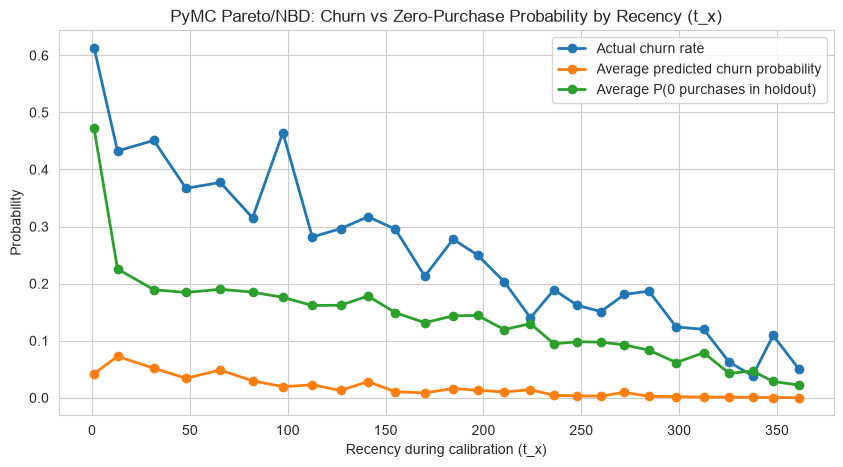

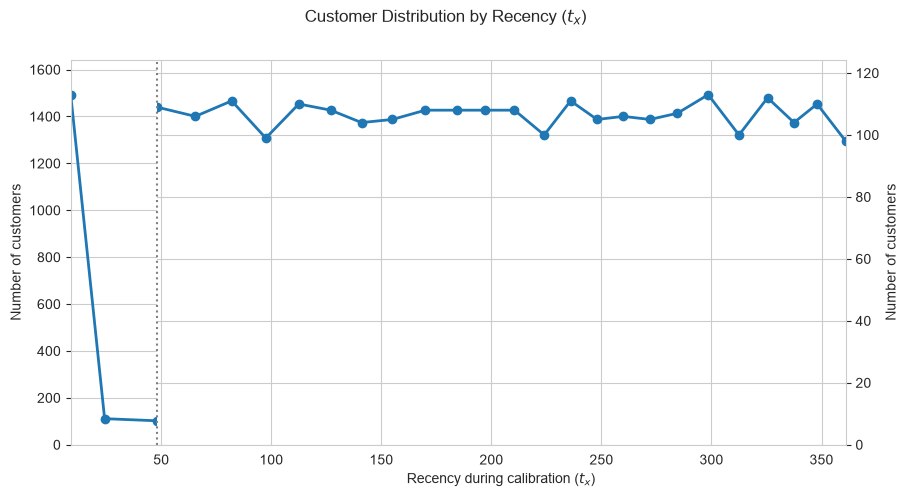

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

holdout_customers = set(df_holdout["Customer ID"].unique())

evaluation["actual_churned"] = (
    ~evaluation["customer_id"].isin(holdout_customers)
).astype(int)

evaluation["p_alive"] = np.asarray(
    model.expected_probability_alive(data=summary_cal)
).ravel()

evaluation["p0"] = np.asarray(
    model.expected_purchase_probability(
        data=summary_cal,
        n_purchases=0,
        future_t=holdout_period
    )
).ravel()

plot_data = evaluation.dropna(subset=["p_alive", "p0", "actual_churned", "recency"]).copy()
plot_data["pred_churn_prob"] = 1 - plot_data["p_alive"]

# 40 classes for t_x (recency)
plot_data["tx_class"] = pd.qcut(
    plot_data["recency"],
    q=40,
    duplicates="drop"
)

tx_summary = (
    plot_data
    .groupby("tx_class", observed=True)
    .agg(
        actual_churn_rate=("actual_churned", "mean"),
        avg_pred_churn_prob=("pred_churn_prob", "mean"),
        avg_p0=("p0", "mean"),
        n_customers=("actual_churned", "size")
    )
    .reset_index()
)

tx_summary["tx_mid"] = tx_summary["tx_class"].apply(lambda x: (x.left + x.right) / 2)
tx_summary = tx_summary.sort_values("tx_mid").reset_index(drop=True)

# --------------------------------------------------
# Figure 1: churn-related curves vs t_x
# --------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    tx_summary["tx_mid"],
    tx_summary["actual_churn_rate"],
    marker="o",
    linewidth=2,
    label="Actual churn rate"
)

plt.plot(
    tx_summary["tx_mid"],
    tx_summary["avg_pred_churn_prob"],
    marker="o",
    linewidth=2,
    label="Average predicted churn probability"
)

plt.plot(
    tx_summary["tx_mid"],
    tx_summary["avg_p0"],
    marker="o",
    linewidth=2,
    label="Average P(0 purchases in holdout)"
)

plt.xlabel("Recency during calibration (t_x)")
plt.ylabel("Probability")
plt.title("PyMC Pareto/NBD: Churn vs Zero-Purchase Probability by Recency (t_x)")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# Figure 2: customer distribution by t_x
# --------------------------------------------------
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(10, 5),
    gridspec_kw={"width_ratios": [3, max(len(tx_summary)-3, 1)]},
    sharex=False,
    sharey=False
)

left = tx_summary.iloc[:3]
right = tx_summary.iloc[3:]

ax1.plot(left["tx_mid"], left["n_customers"], marker="o", linewidth=2)
ax2.plot(right["tx_mid"], right["n_customers"], marker="o", linewidth=2)

# x limits
ax1.set_xlim(left["tx_mid"].min(), left["tx_mid"].max())
ax2.set_xlim(right["tx_mid"].min(), right["tx_mid"].max())

# independent y limits
ax1.set_ylim(0, left["n_customers"].max() * 1.1)
ax2.set_ylim(0, right["n_customers"].max() * 1.1)

# remove touching spines
ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)

# y axes
ax1.yaxis.set_ticks_position("left")
ax1.yaxis.set_label_position("left")
ax1.set_ylabel("Number of customers")

ax2.yaxis.set_ticks_position("right")
ax2.yaxis.set_label_position("right")
ax2.set_ylabel("Number of customers")

# x labels

ax2.set_xlabel("Recency during calibration ($t_x$)")

# dotted separator
ax1.axvline(
    left["tx_mid"].max(),
    color="gray",
    linestyle=":",
    linewidth=1.5
)

ax2.axvline(
    right["tx_mid"].min(),
    color="gray",
    linestyle=":",
    linewidth=1.5
)

# -------------------------------
# Custom ticks every 50 units
# -------------------------------
xmin = int(np.floor(tx_summary["tx_mid"].min() / 50) * 50)
xmax = int(np.ceil(tx_summary["tx_mid"].max() / 50) * 50)

ticks = np.arange(xmin, xmax + 1, 50)

ax1.set_xticks([t for t in ticks if left["tx_mid"].min() <= t <= left["tx_mid"].max()])
ax2.set_xticks([t for t in ticks if right["tx_mid"].min() <= t <= right["tx_mid"].max()])

ax1.grid(True)
ax2.grid(True)

fig.suptitle("Customer Distribution by Recency ($t_x$)")

plt.subplots_adjust(wspace=0)
plt.show()

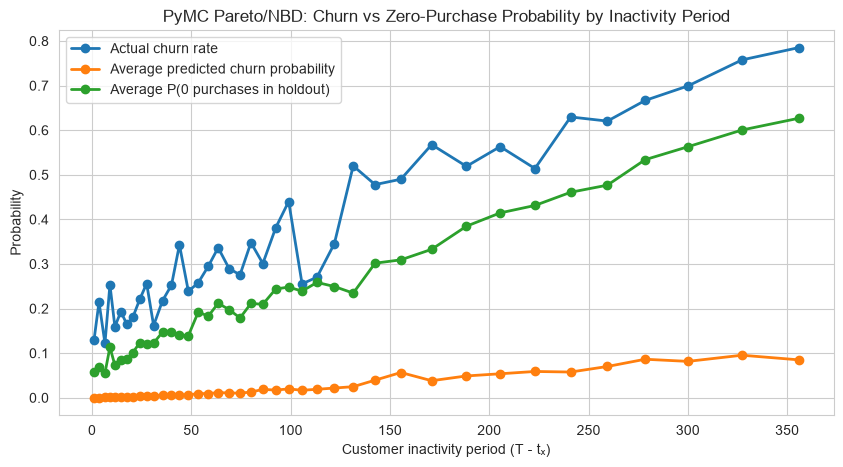

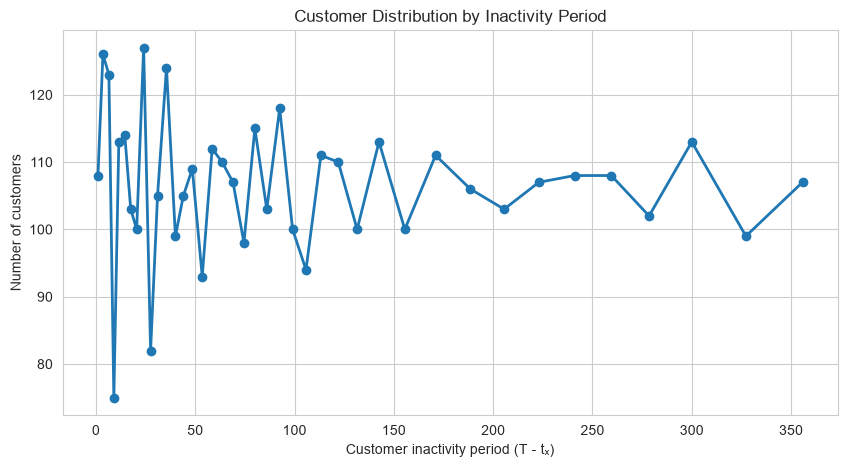

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

holdout_customers = set(df_holdout["Customer ID"].unique())

evaluation["actual_churned"] = (
    ~evaluation["customer_id"].isin(holdout_customers)
).astype(int)

evaluation["p_alive"] = np.asarray(
    model.expected_probability_alive(data=summary_cal)
).ravel()

evaluation["p0"] = np.asarray(
    model.expected_purchase_probability(
        data=summary_cal,
        n_purchases=0,
        future_t=holdout_period
    )
).ravel()

plot_data = evaluation.dropna(subset=["p_alive", "p0", "actual_churned", "T", "recency"]).copy()
plot_data["pred_churn_prob"] = 1 - plot_data["p_alive"]
plot_data["inactivity"] = plot_data["T"] - plot_data["recency"]

# 40 classes for inactivity period
plot_data["inact_class"] = pd.qcut(
    plot_data["inactivity"],
    q=40,
    duplicates="drop"
)

inact_summary = (
    plot_data
    .groupby("inact_class", observed=True)
    .agg(
        actual_churn_rate=("actual_churned", "mean"),
        avg_pred_churn_prob=("pred_churn_prob", "mean"),
        avg_p0=("p0", "mean"),
        n_customers=("actual_churned", "size")
    )
    .reset_index()
)

inact_summary["inact_mid"] = inact_summary["inact_class"].apply(
    lambda x: (x.left + x.right) / 2
)
inact_summary = inact_summary.sort_values("inact_mid").reset_index(drop=True)

# --------------------------------------------------
# Figure 1: churn-related curves vs inactivity period
# --------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    inact_summary["inact_mid"],
    inact_summary["actual_churn_rate"],
    marker="o",
    linewidth=2,
    label="Actual churn rate"
)

plt.plot(
    inact_summary["inact_mid"],
    inact_summary["avg_pred_churn_prob"],
    marker="o",
    linewidth=2,
    label="Average predicted churn probability"
)

plt.plot(
    inact_summary["inact_mid"],
    inact_summary["avg_p0"],
    marker="o",
    linewidth=2,
    label="Average P(0 purchases in holdout)"
)

plt.xlabel("Customer inactivity period (T - tₓ)")
plt.ylabel("Probability")
plt.title("PyMC Pareto/NBD: Churn vs Zero-Purchase Probability by Inactivity Period")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# Figure 2: customer distribution by inactivity period
# --------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    inact_summary["inact_mid"],
    inact_summary["n_customers"],
    marker="o",
    linewidth=2
)

plt.xlabel("Customer inactivity period (T - tₓ)")
plt.ylabel("Number of customers")
plt.title("Customer Distribution by Inactivity Period")
plt.grid(True)
plt.show()

## Number of Purchases in the Holdout Period: Predicted vs Actual

In [22]:
# Predict expected purchases during the holdout period
pred = model.expected_purchases(
    data=summary_cal,
    future_t=holdout_period
)

evaluation = summary_cal.copy()
evaluation["pred_purchases"] = np.asarray(pred).ravel()

# Actual purchases in the holdout period
actual = (
    df_holdout
    .groupby("Customer ID")["order_id"]
    .nunique()
)

evaluation["actual_purchases"] = (
    evaluation["customer_id"]
    .map(actual)
    .fillna(0)
)

print("Total actual purchases   :", evaluation["actual_purchases"].sum())
print("Total predicted purchases:", evaluation["pred_purchases"].sum())

print("MAE :", mean_absolute_error(
    evaluation["actual_purchases"],
    evaluation["pred_purchases"]
))

print("RMSE:", np.sqrt(mean_squared_error(
    evaluation["actual_purchases"],
    evaluation["pred_purchases"]
)))

Total actual purchases   : 12565.0
Total predicted purchases: 17046.198618565737
MAE : 2.2809983224622052
RMSE: 3.4387548112463997


In [23]:
print("Pearson :", pearsonr(
    evaluation["actual_purchases"],
    evaluation["pred_purchases"]
)[0])

print("Spearman:", spearmanr(
    evaluation["actual_purchases"],
    evaluation["pred_purchases"]
)[0])

Pearson : 0.8390243965726694
Spearman: 0.5916408776730966


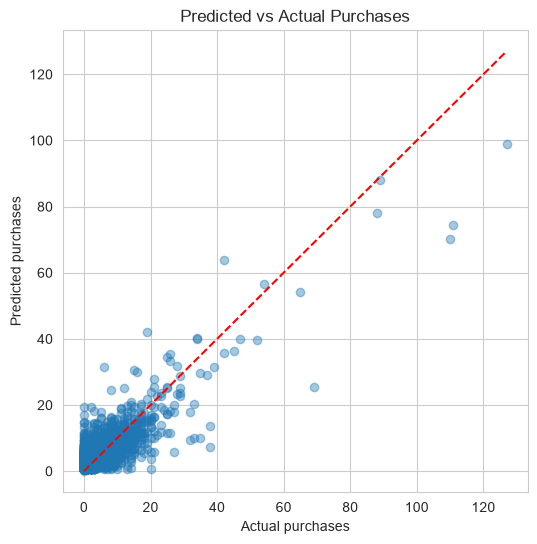

In [24]:
plt.figure(figsize=(6,6))

plt.scatter(
    evaluation["actual_purchases"],
    evaluation["pred_purchases"],
    alpha=0.4
)

m = max(
    evaluation["actual_purchases"].max(),
    evaluation["pred_purchases"].max()
)

plt.plot([0,m],[0,m],'r--')

plt.xlabel("Actual purchases")
plt.ylabel("Predicted purchases")
plt.title("Predicted vs Actual Purchases")

plt.show()

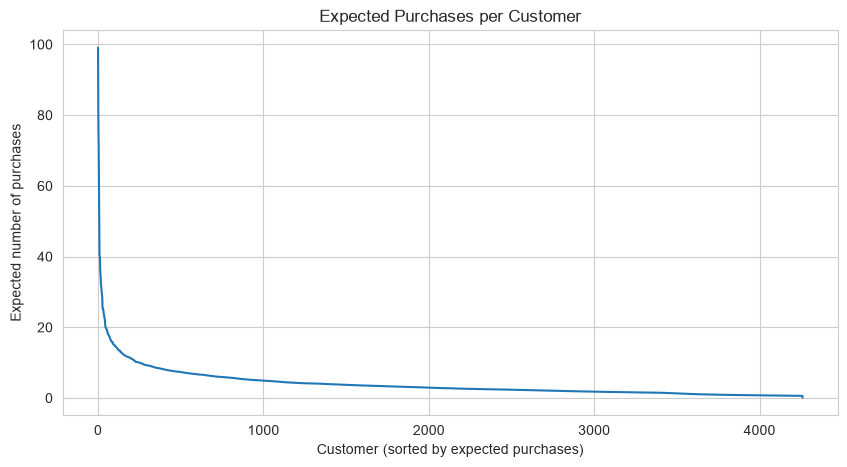

In [25]:
plot_data = (
    evaluation["pred_purchases"]
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 5))

plt.plot(
    plot_data,
    linewidth=1.5
)

plt.xlabel("Customer (sorted by expected purchases)")
plt.ylabel("Expected number of purchases")
plt.title("Expected Purchases per Customer")
plt.grid(True)

plt.show()

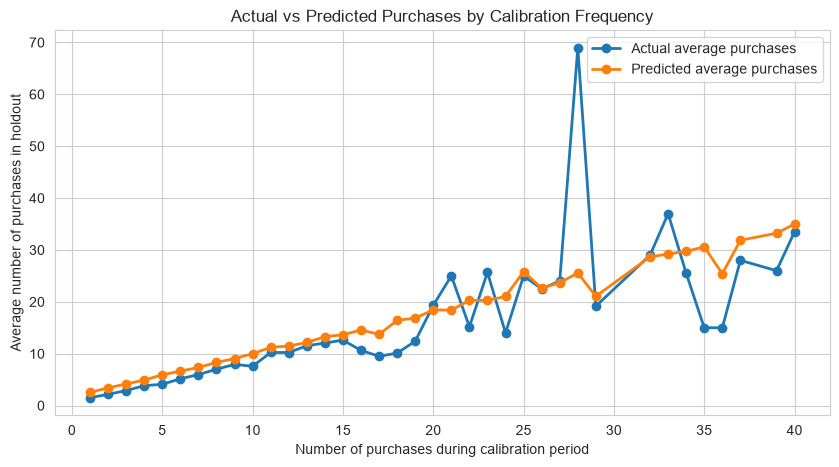

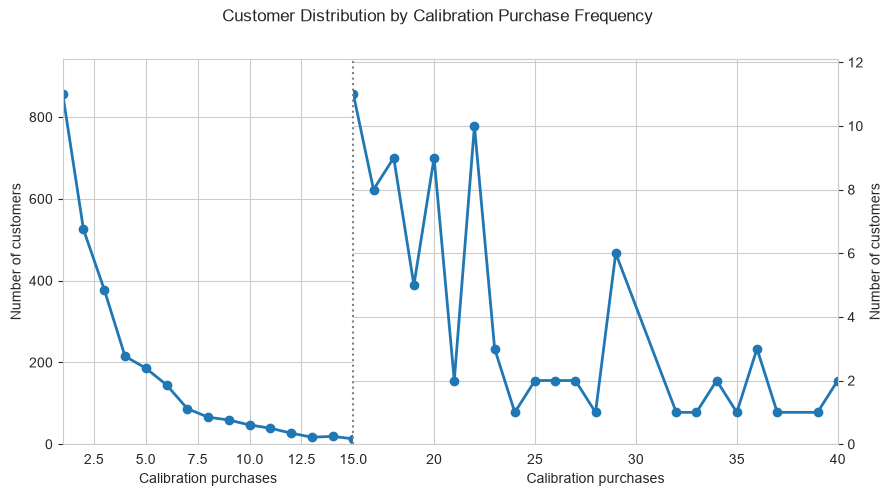

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# predicted purchases for the holdout period
evaluation["pred_purchases"] = np.asarray(
    model.expected_purchases(data=summary_cal, future_t=holdout_period)
).ravel()

# actual purchases in holdout
actual = df_holdout.groupby("Customer ID")["order_id"].nunique()
evaluation["actual_purchases"] = evaluation["customer_id"].map(actual).fillna(0)

plot_data = evaluation.dropna(subset=["pred_purchases", "actual_purchases"]).copy()

freq_summary = (
    plot_data[(plot_data["frequency"] >= 1) & (plot_data["frequency"] <= 40)]
    .groupby("frequency")
    .agg(
        actual_avg_purchases=("actual_purchases", "mean"),
        pred_avg_purchases=("pred_purchases", "mean"),
        n_customers=("customer_id", "size"),
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(
    freq_summary["frequency"],
    freq_summary["actual_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Actual average purchases",
)
plt.plot(
    freq_summary["frequency"],
    freq_summary["pred_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Predicted average purchases",
)
plt.xlabel("Number of purchases during calibration period")
plt.ylabel("Average number of purchases in holdout")
plt.title("Actual vs Predicted Purchases by Calibration Frequency")
plt.grid(True)
plt.legend()
plt.show()

#===================================================================
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(10, 5),
    gridspec_kw={"width_ratios": [15, 25]},
    sharex=False,
    sharey=False
)

left = freq_summary[freq_summary["frequency"] <= 15]
right = freq_summary[freq_summary["frequency"] >= 16]

ax1.plot(left["frequency"], left["n_customers"], marker="o", linewidth=2)
ax2.plot(right["frequency"], right["n_customers"], marker="o", linewidth=2)

# x limits
ax1.set_xlim(1, 15)
ax2.set_xlim(16, 40)

# independent y limits
ax1.set_ylim(0, left["n_customers"].max() * 1.1)
ax2.set_ylim(0, right["n_customers"].max() * 1.1)

# remove touching spines
ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)

# left y-axis
ax1.yaxis.set_ticks_position("left")
ax1.yaxis.set_label_position("left")
ax1.set_ylabel("Number of customers")

# right y-axis
ax2.yaxis.set_ticks_position("right")
ax2.yaxis.set_label_position("right")
ax2.set_ylabel("Number of customers")

# x labels
ax1.set_xlabel("Calibration purchases")
ax2.set_xlabel("Calibration purchases")


# dotted separator
ax1.axvline(
    x=15,
    color="gray",
    linestyle=":",
    linewidth=1.5
)


ax2.axvline(
    x=16,
    color="gray",
    linestyle=":",
    linewidth=1.5
)


fig.suptitle("Customer Distribution by Calibration Purchase Frequency")

# panels touch each other
plt.subplots_adjust(wspace=0)

plt.show()

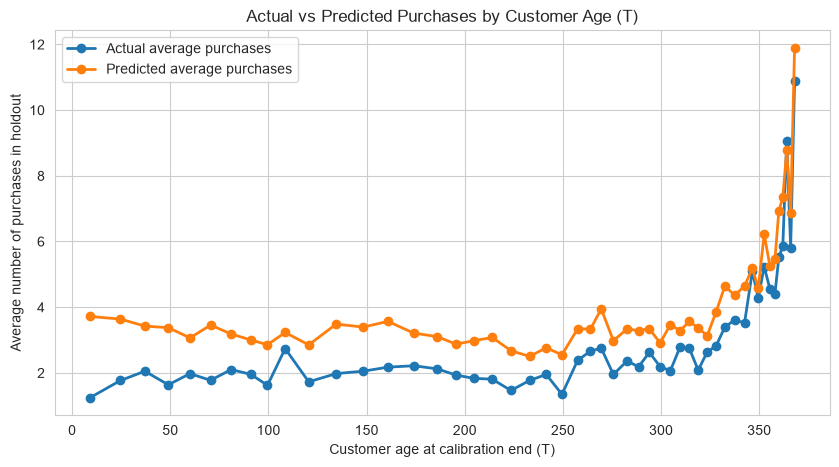

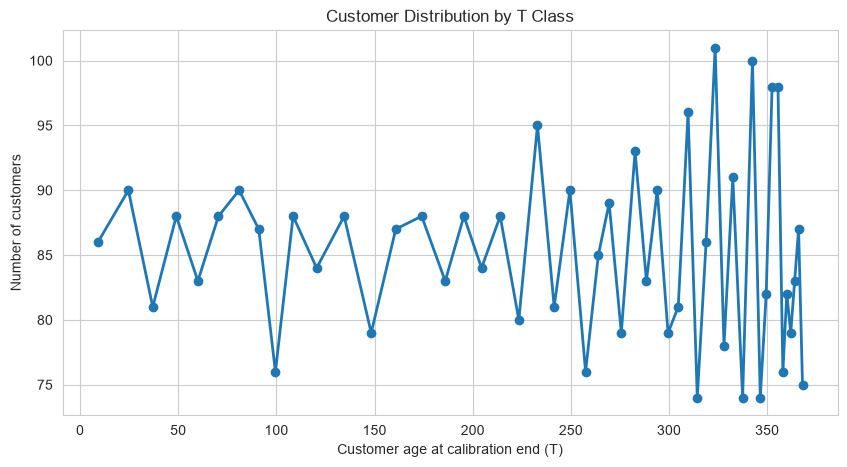

In [44]:
# --------------------------------------------------
# 1) Predict and attach actual purchases
# --------------------------------------------------
evaluation["pred_purchases"] = np.asarray(
    model.expected_purchases(data=summary_cal, future_t=holdout_period)
).ravel()

actual = df_holdout.groupby("Customer ID")["order_id"].nunique()
evaluation["actual_purchases"] = evaluation["customer_id"].map(actual).fillna(0)

plot_data = evaluation.dropna(subset=["pred_purchases", "actual_purchases", "T"]).copy()

# --------------------------------------------------
# 2) Create about 50 classes for T using quantiles
#    T = customer age at end of calibration period
# --------------------------------------------------
plot_data["T_class"] = pd.qcut(
    plot_data["T"],
    q=50,
    duplicates="drop"
)

T_summary = (
    plot_data
    .groupby("T_class", observed=True)
    .agg(
        actual_avg_purchases=("actual_purchases", "mean"),
        pred_avg_purchases=("pred_purchases", "mean"),
        n_customers=("customer_id", "size")
    )
    .reset_index()
)

# Use class midpoints for plotting on the x-axis
T_summary["T_mid"] = T_summary["T_class"].apply(
    lambda x: (x.left + x.right) / 2
)

T_summary = T_summary.sort_values("T_mid").reset_index(drop=True)

# --------------------------------------------------
# 3) Figure 1: Actual vs Predicted purchases by T class
# --------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    T_summary["T_mid"],
    T_summary["actual_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Actual average purchases"
)

plt.plot(
    T_summary["T_mid"],
    T_summary["pred_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Predicted average purchases"
)

plt.xlabel("Customer age at calibration end (T)")
plt.ylabel("Average number of purchases in holdout")
plt.title("Actual vs Predicted Purchases by Customer Age (T)")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# 4) Figure 2: Customer distribution by T class
# --------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    T_summary["T_mid"],
    T_summary["n_customers"],
    marker="o",
    linewidth=2
)

plt.xlabel("Customer age at calibration end (T)")
plt.ylabel("Number of customers")
plt.title("Customer Distribution by T Class")
plt.grid(True)
plt.show()

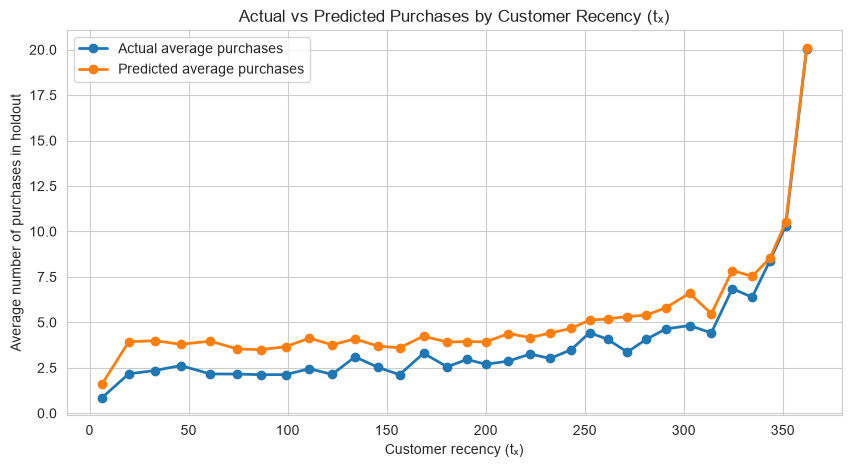

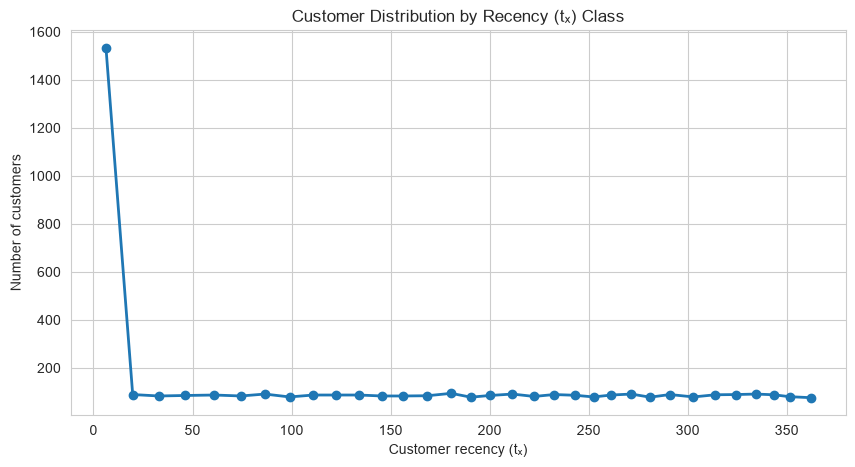

In [45]:
# --------------------------------------------------
# Create ~50 recency (t_x) classes
# --------------------------------------------------
plot_data = evaluation.dropna(
    subset=["pred_purchases", "actual_purchases", "recency"]
).copy()

plot_data["tx_class"] = pd.qcut(
    plot_data["recency"],
    q=50,
    duplicates="drop"
)

tx_summary = (
    plot_data
    .groupby("tx_class", observed=True)
    .agg(
        actual_avg_purchases=("actual_purchases", "mean"),
        pred_avg_purchases=("pred_purchases", "mean"),
        n_customers=("customer_id", "size")
    )
    .reset_index()
)

tx_summary["tx_mid"] = tx_summary["tx_class"].apply(
    lambda x: (x.left + x.right) / 2
)

tx_summary = tx_summary.sort_values("tx_mid").reset_index(drop=True)

# --------------------------------------------------
# Figure 1
# --------------------------------------------------
plt.figure(figsize=(10,5))

plt.plot(
    tx_summary["tx_mid"],
    tx_summary["actual_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Actual average purchases"
)

plt.plot(
    tx_summary["tx_mid"],
    tx_summary["pred_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Predicted average purchases"
)

plt.xlabel("Customer recency (tₓ)")
plt.ylabel("Average number of purchases in holdout")
plt.title("Actual vs Predicted Purchases by Customer Recency (tₓ)")
plt.grid(True)
plt.legend()

plt.show()

# --------------------------------------------------
# Figure 2
# --------------------------------------------------
plt.figure(figsize=(10,5))

plt.plot(
    tx_summary["tx_mid"],
    tx_summary["n_customers"],
    marker="o",
    linewidth=2
)

plt.xlabel("Customer recency (tₓ)")
plt.ylabel("Number of customers")
plt.title("Customer Distribution by Recency (tₓ) Class")
plt.grid(True)

plt.show()

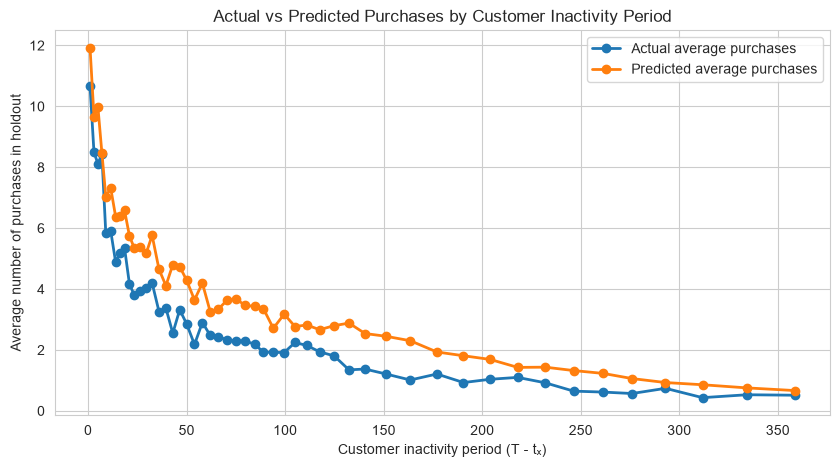

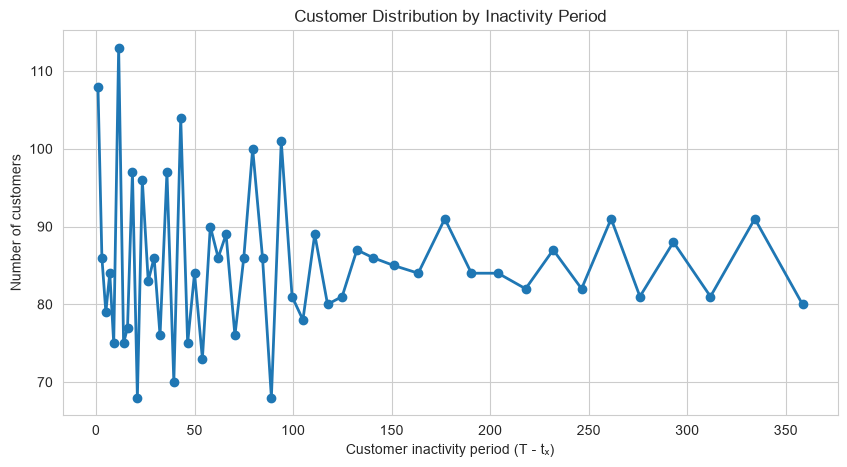

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# customer inactivity period = T - t_x
plot_data = evaluation.dropna(
    subset=["pred_purchases", "actual_purchases", "T", "recency"]
).copy()

plot_data["inactivity"] = plot_data["T"] - plot_data["recency"]

# 50 quantile-based classes
plot_data["inactivity_class"] = pd.qcut(
    plot_data["inactivity"],
    q=50,
    duplicates="drop"
)

inact_summary = (
    plot_data
    .groupby("inactivity_class", observed=True)
    .agg(
        actual_avg_purchases=("actual_purchases", "mean"),
        pred_avg_purchases=("pred_purchases", "mean"),
        n_customers=("customer_id", "size")
    )
    .reset_index()
)

inact_summary["inact_mid"] = inact_summary["inactivity_class"].apply(
    lambda x: (x.left + x.right) / 2
)

inact_summary = inact_summary.sort_values("inact_mid").reset_index(drop=True)

# Figure 1: actual vs predicted purchases by inactivity period
plt.figure(figsize=(10, 5))

plt.plot(
    inact_summary["inact_mid"],
    inact_summary["actual_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Actual average purchases"
)

plt.plot(
    inact_summary["inact_mid"],
    inact_summary["pred_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Predicted average purchases"
)

plt.xlabel("Customer inactivity period (T - tₓ)")
plt.ylabel("Average number of purchases in holdout")
plt.title("Actual vs Predicted Purchases by Customer Inactivity Period")
plt.grid(True)
plt.legend()
plt.show()

# Figure 2: customer distribution by inactivity period
plt.figure(figsize=(10, 5))

plt.plot(
    inact_summary["inact_mid"],
    inact_summary["n_customers"],
    marker="o",
    linewidth=2
)

plt.xlabel("Customer inactivity period (T - tₓ)")
plt.ylabel("Number of customers")
plt.title("Customer Distribution by Inactivity Period")
plt.grid(True)
plt.show()